In [1]:
# in this notebook, I want to create the beginnings of something I can use for trend analysis
# i have a lot of great data, and i need to be able to see the trends per day

In [2]:
import pandas as pd

# Preparing Data

In [3]:
data = 'data/verdant_eye/claims_20260518.json.gz'

df = pd.read_json(data)
df['date_added'] = pd.to_datetime(df['date_added'].astype('int64'), unit='ms')

df.head()

,date_added,date,hour,domain,url_domain,claim,url
0,2025-12-20 16:56:39,20251220,16,thenationalpulse.com,thenationalpulse.com,A UN judge asserts immunity after being arrest...,https://thenationalpulse.com/2025/03/14/un-jud...
1,2025-12-20 16:48:41,20251220,16,independent.co.uk,independent.co.uk,Claims that a suspect in the Brown University ...,https://independent.co.uk/news/world/americas/...
2,2025-12-20 11:08:16,20251220,11,nypost.com,nypost.com,New York police officers were wounded in a sho...,https://nypost.com/2025/12/20/us-news/new-york...
3,2025-12-20 11:09:50,20251220,11,clickondetroit.com,clickondetroit.com,A dispute on a bike path leads to a fatality a...,https://clickondetroit.com/news/local/2025/12/...
4,2025-12-20 11:09:50,20251220,11,clickondetroit.com,clickondetroit.com,A family claims a hospital lost part of a pati...,https://clickondetroit.com/news/local/2025/12/...


In [4]:
df.shape

(472960, 7)

In [5]:
drop_terms = [
    'news article', 'news topic', 'status update', 'event', 'ticket', 'not identified', 
    'not enough information', 'news update', 'no specific claim', 'no claim', 'unspecified news',
    'article related to', 'claim related to', 'claim not specified', 'recent news post', 'a specific report',
    'lacks specific claim', 'unclear claim', 'unspecified incident', 'no claims available',
    'news story', 'news report', 'news post', 'news item', 'current news', 'unknown claim', 'uncertain claim',
    'video clip is available', 'no clear claim', 'claim not discernible', 'not specified', 'unspecified', 
    'claim is unclear', 'news related', 'specific news', 'unspecified content'
]

pattern = '|'.join(drop_terms)

df = df[~df['claim'].str.contains(pattern, case=False, na=False)]

In [6]:
df.shape

(359684, 7)

# Clustering

Clustering is useful for seeing the kinds of things that are happening. If you want to do trend analysis, start with clustering or filtering. You will want to have clustering in your skillset/toolset. Here is my graph+nlp approach, my own approach.

Tweak the similarity threshold to get what you want. 1 is exact match. 0 is no match. 0.5-0.8 is typically pretty sweet, but it depends on what you are doing. Sometimes lower is useful. Sometimes very high is useful. Be thoughtful about what you are trying to do and it will make sense. Ask me if you would like to learn more.

In [7]:
import pandas as pd
import numpy as np
import networkx as nx
import community as community_louvain

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [8]:
def cluster_text(texts, similarity_threshold=0.5):

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        lowercase=True,
        sublinear_tf=True
    )

    tfidf_matrix = vectorizer.fit_transform(texts)

    similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)
    adj_matrix = (similarity_matrix > similarity_threshold).astype(int)

    G = nx.from_numpy_array(adj_matrix)
    partition = community_louvain.best_partition(G, resolution=0.5, random_state=1337) 

    return list(partition.values())

In [9]:
# i want to see this by day, week, month, 3 months

df.head()

,date_added,date,hour,domain,url_domain,claim,url
0,2025-12-20 16:56:39,20251220,16,thenationalpulse.com,thenationalpulse.com,A UN judge asserts immunity after being arrest...,https://thenationalpulse.com/2025/03/14/un-jud...
1,2025-12-20 16:48:41,20251220,16,independent.co.uk,independent.co.uk,Claims that a suspect in the Brown University ...,https://independent.co.uk/news/world/americas/...
2,2025-12-20 11:08:16,20251220,11,nypost.com,nypost.com,New York police officers were wounded in a sho...,https://nypost.com/2025/12/20/us-news/new-york...
3,2025-12-20 11:09:50,20251220,11,clickondetroit.com,clickondetroit.com,A dispute on a bike path leads to a fatality a...,https://clickondetroit.com/news/local/2025/12/...
4,2025-12-20 11:09:50,20251220,11,clickondetroit.com,clickondetroit.com,A family claims a hospital lost part of a pati...,https://clickondetroit.com/news/local/2025/12/...


In [10]:
latest = df['date_added'].max()

last_day_df = df[df['date_added'] >= latest - pd.Timedelta(days=1)].copy()

last_week_df = df[df['date_added'] >= latest - pd.Timedelta(weeks=1)].copy()

last_month_df = df[df['date_added'] >= latest - pd.Timedelta(days=30)].copy()

In [11]:
last_month_df.shape

(90425, 7)

In [12]:
last_week_df.shape

(23021, 7)

In [13]:
last_day_df.shape

(3011, 7)

# Last Day Clusters

In [14]:
last_day_df['cluster'] = cluster_text(last_day_df['claim'], similarity_threshold=0.4) # reducing to capture broader topics
check_df = last_day_df

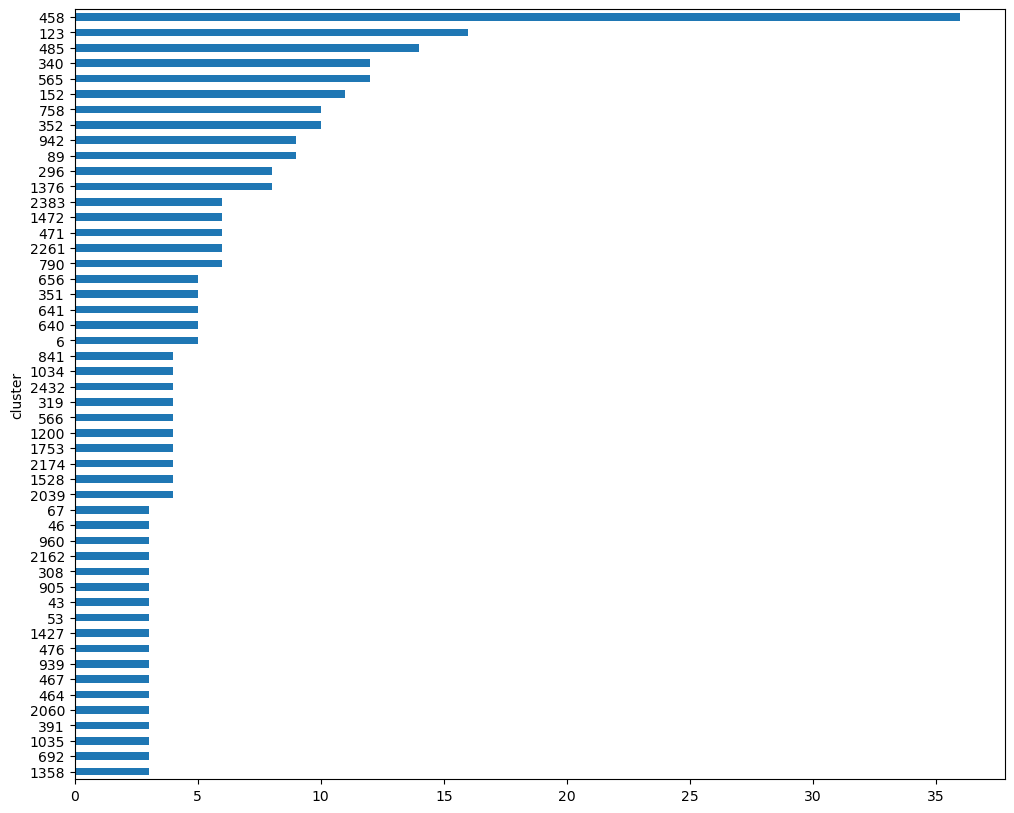

In [15]:
check_df['cluster'].value_counts()[0:50].plot.barh(figsize=(12,10)).invert_yaxis()

In [16]:
top_clusters = check_df['cluster'].value_counts().index.values
top_clusters

array([458, 123, 485, ..., 926, 927, 934], dtype=int64)

In [17]:
for cluster in top_clusters[0:100]:
    
    print('cluster: {}'.format(cluster))
    
    cluster_data = check_df[check_df['cluster']==cluster].head(20)['claim'].values
    print(cluster_data)
    
    print()

cluster: 458
['Report on shootings in Austin, Texas'
 'Report on shootings in Austin, Texas'
 'Random shootings have been reported in Austin, Texas, and police are advising residents.'
 'Ten random shootings over the weekend have resulted in four injuries in Austin, according to the mayor.'
 '10 random weekend shootings occurred, resulting in 4 injuries in Austin according to the mayor.'
 'Report on a shooting spree in Austin with multiple victims and a shelter-in-place alert.'
 'Multiple shootings occurred in Texas, specifically in Austin.'
 '4 injured in 10 random shootings in Austin'
 '4 injured in 10 random shootings in Austin'
 'Four people were injured in ten random shootings in Austin, with two suspects in custody according to police.'
 '10 random weekend shootings leave 4 injured in Austin, Texas, mayor says'
 'Four people injured in ten random shootings in Austin, two suspects in custody according to police.'
 'Four people were injured in 10 random shootings in Austin, and pol

# Last Week Clusters

In [18]:
last_week_df['cluster'] = cluster_text(last_week_df['claim'], similarity_threshold=0.4) # reducing to capture broader topics
check_df = last_week_df

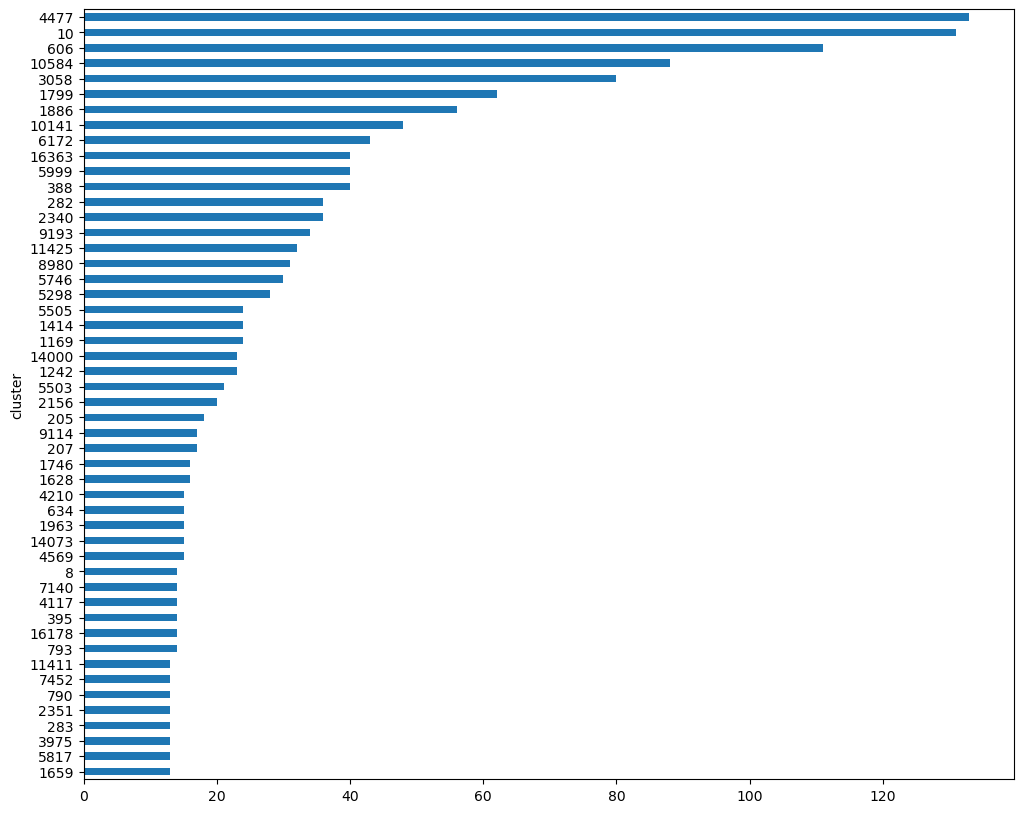

In [19]:
check_df['cluster'].value_counts()[0:50].plot.barh(figsize=(12,10)).invert_yaxis()

In [20]:
top_clusters = check_df['cluster'].value_counts().index.values
top_clusters

array([4477,   10,  606, ..., 6519, 6520, 3182], dtype=int64)

In [21]:
for cluster in top_clusters[0:100]:
    
    print('cluster: {}'.format(cluster))
    
    cluster_data = check_df[check_df['cluster']==cluster].head(20)['claim'].values
    print(cluster_data)
    
    print()

cluster: 4477
['Touring production of The Sound of Music in San Diego'
 'An announcement for a basketball game between the Los Angeles Sparks and the Indiana Fever.'
 'Cornelia Murr is performing in San Francisco on May 13, 2026.'
 'Texas is the Reason band is performing in San Francisco on May 13, 2026.'
 'Circus Caballero will be performing in Bell, Los Angeles on May 13, 2026.'
 'Anna Ash performance in San Francisco on May 14, 2026 at 7:00 PM'
 "'The Sound of Music' will be performed in Los Angeles on May 13, 2026."
 'Portland Fire vs. New York Liberty game in Portland on May 12, 2026 at 7:00 PM'
 'Carrot Top is performing in Las Vegas on May 12, 2026 at 8:00 PM.'
 'Chippendales is performing in Las Vegas on May 12, 2026 at 8:00 PM.'
 'Jared Benjamin is performing in Vancouver on May 12, 2026 at 8:00 PM.'
 "Jason Bonham's Led Zeppelin Evening is performing in Colorado Springs on May 12, 2026 at 8:00 PM."
 'Lucy Dacus is performing in Vancouver on May 12, 2026 at 8:00 PM.'
 'Modest 

# Last Month

In [22]:
last_month_df = last_month_df.sample(25000)
last_month_df['cluster'] = cluster_text(last_month_df['claim'], similarity_threshold=0.4) # reducing to capture broader topics
check_df = last_month_df

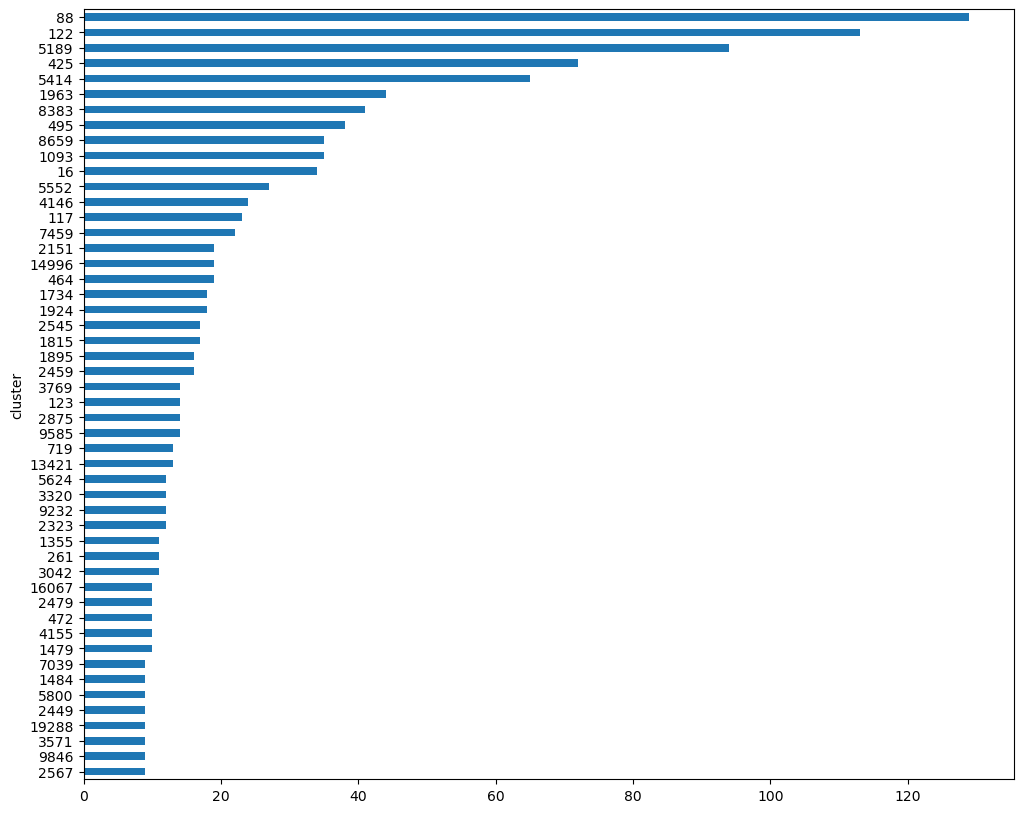

In [23]:
check_df['cluster'].value_counts()[0:50].plot.barh(figsize=(12,10)).invert_yaxis()

In [24]:
top_clusters = check_df['cluster'].value_counts().index.values
top_clusters

array([   88,   122,  5189, ...,  7842,  7841, 17777], dtype=int64)

In [25]:
for cluster in top_clusters[0:100]:
    
    print('cluster: {}'.format(cluster))
    
    cluster_data = check_df[check_df['cluster']==cluster].head(20)['claim'].values
    print(cluster_data)
    
    print()

cluster: 88
['A possible case of hantavirus related to a cruise ship outbreak'
 'Hantavirus outbreak on cruise ship claims three lives'
 'Report on hantavirus outbreak.'
 'Human-to-human transmission of hantavirus suspected on a cruise ship'
 'Information about hantavirus illness suspected on a cruise'
 'Passengers from a cruise ship are linked to a hantavirus outbreak in Australia.'
 'A suspected outbreak of the rare hantavirus on a cruise ship in the Atlantic Ocean has killed 3 people.'
 'Hantavirus outbreak linked to a cruise ship affecting Nebraska passengers.'
 'A U.S. citizen tested positive for hantavirus after being on a cruise ship.'
 'A hantavirus outbreak linked to a cruise ship has resulted in a traveler death in Virginia.'
 'Two passengers tested positive for hantavirus following a cruise ship evacuation, with a third showing symptoms.'
 'Claims about Hantavirus outbreak concerns related to cruise ships.'
 'Two passengers tested positive for hantavirus following a cruise s